# Customer segments: who brings the revenue, and who is slipping away

This notebook is the source of truth for every number in the README and the Power BI report. Run it top to bottom from a fresh clone:

1. **Clean** the invoice lines (the data health check)
2. **Score** each customer on recency, frequency and spend
3. **Group** customers into champions, loyal, new, at risk and lost
4. **Cohorts:** how many of each month's new customers come back
5. **Check** the key numbers again in SQL
6. **Save** `data/invoices.csv` and `data/customers.csv` for Power BI

In [1]:
from pathlib import Path
import urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import duckdb

DATA = Path("../data")
DOCS = Path("../docs")
RAW = DATA / "online_retail_II.xlsx"
URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

# The portfolio theme's colours, the same slots as the Power BI report: blues for the base, danger for "at risk"
NAVY, SLATE, LIGHT, DANGER = "#0E1630", "#4A5675", "#E2E7F1", "#C2410C"
SEGMENTS = ["Champions", "Loyal", "New", "At risk", "Lost"]
SEGMENT_COLOURS = {"Champions": "#2563EB", "Loyal": "#8DB0FF", "New": "#C7D7FE", "At risk": DANGER, "Lost": SLATE}
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 13, "figure.dpi": 110})

## 1. Read the raw invoice lines

The source file has one sheet per year. It is downloaded once (about 45 MB); reading the two sheets takes about three minutes.

In [2]:
if not RAW.exists():
    zip_path = DATA / "online_retail_ii.zip"
    urllib.request.urlretrieve(URL, zip_path)
    zipfile.ZipFile(zip_path).extractall(DATA)

sheets = pd.read_excel(RAW, sheet_name=None, dtype={"Invoice": str, "StockCode": str})
raw = pd.concat(sheets.values(), ignore_index=True)
print({name: len(sheet) for name, sheet in sheets.items()})
print(f"{len(raw):,} invoice lines from {raw.InvoiceDate.min():%d %b %Y} to {raw.InvoiceDate.max():%d %b %Y}")
raw.head()

{'Year 2009-2010': 525461, 'Year 2010-2011': 541910}
1,067,371 invoice lines from 01 Dec 2009 to 09 Dec 2011


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Clean: the data health check

One rule per step, each with the number of lines it removes:

1. **Exact duplicate lines.** The two yearly sheets overlap on 1 to 9 December 2010, so those days appear twice.
2. **No customer ID.** A customer we cannot identify cannot be scored.
3. **Not a product.** Product codes start with five digits; postage, bank charges, fees and manual adjustments do not.
4. **Zero price.** Free lines carry no revenue.

Returns stay in: an invoice number starting with **C** is a return or a cancelled order. Returns are taken off the customer's spend, so an order cancelled ten minutes later does not make a customer look like a top spender.

In [3]:
health = [("Raw invoice lines", len(raw))]
lines = raw.drop_duplicates()
health.append(("Exact duplicates removed", len(lines)))
lines = lines[lines["Customer ID"].notna()]
health.append(("No customer ID removed", len(lines)))
lines = lines[lines["StockCode"].str.match(r"^\d{5}")]
health.append(("Non-product lines removed", len(lines)))
lines = lines[lines["Price"] > 0]
health.append(("Zero-price lines removed", len(lines)))

health = pd.DataFrame(health, columns=["step", "lines_left"])
health["removed"] = -health["lines_left"].diff().fillna(0).astype(int)

deduped = raw.drop_duplicates()
no_id_share = (deduped.Quantity * deduped.Price)[deduped["Customer ID"].isna()].sum() / (deduped.Quantity * deduped.Price).sum()
print(f"Revenue on lines with no customer ID: {no_id_share:.1%}")
health

Revenue on lines with no customer ID: 13.6%


,step,lines_left,removed
0,Raw invoice lines,1067371,0
1,Exact duplicates removed,1033036,34335
2,No customer ID removed,797885,235151
3,Non-product lines removed,794223,3662
4,Zero-price lines removed,794163,60


7,282 return invoices take 709,953 off 17,068,568 of purchases


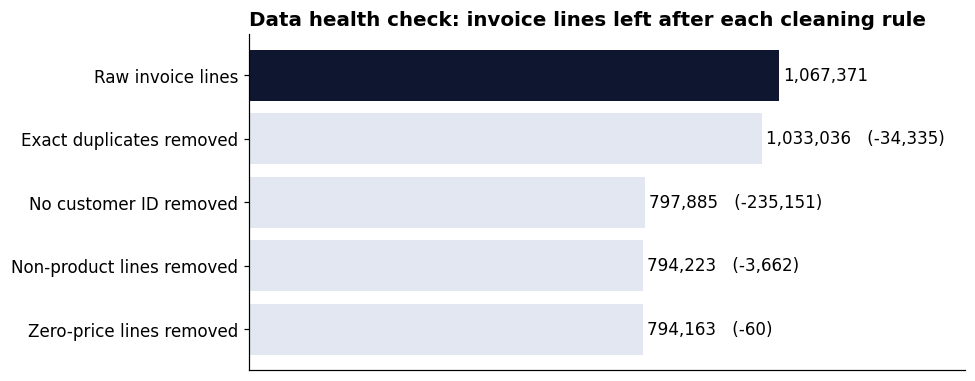

In [4]:
lines = lines.assign(
    customer_id=lines["Customer ID"].astype(int),
    amount=lines["Quantity"] * lines["Price"],
    invoice_type=np.where(lines["Invoice"].str.startswith("C"), "Return", "Purchase"),
)
returns = lines[lines.invoice_type == "Return"]
print(f"{returns.Invoice.nunique():,} return invoices take {-returns.amount.sum():,.0f} off "
      f"{lines[lines.invoice_type == 'Purchase'].amount.sum():,.0f} of purchases")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(health.step[::-1], health.lines_left[::-1], color=[LIGHT] * (len(health) - 1) + [NAVY])
for y, (left, removed) in enumerate(zip(health.lines_left[::-1], health.removed[::-1])):
    ax.text(left + 8000, y, f"{left:,}" + (f"   (-{removed:,})" if removed else ""), va="center")
ax.set_xlim(0, health.lines_left.max() * 1.35)
ax.set_xticks([])
ax.set_title("Data health check: invoice lines left after each cleaning rule", loc="left")
plt.tight_layout(); plt.savefig(DOCS / "data-health.png"); plt.show()

## 3. One row per invoice

An invoice keeps its customer, its earliest time stamp and its total. This is the fact table Power BI loads.

In [5]:
invoices = (lines.groupby("Invoice")
            .agg(customer_id=("customer_id", "first"), invoice_date=("InvoiceDate", "min"),
                 invoice_type=("invoice_type", "first"), amount=("amount", "sum"), country=("Country", "first"))
            .reset_index().rename(columns={"Invoice": "invoice"}))
purchases = invoices[invoices.invoice_type == "Purchase"]
print(f"{len(invoices):,} invoices: {len(purchases):,} purchases and {len(invoices) - len(purchases):,} returns")
invoices.head()

43,876 invoices: 36,594 purchases and 7,282 returns


,invoice,customer_id,invoice_date,invoice_type,amount,country
0,489434,13085,2009-12-01 07:45:00,Purchase,505.30,United Kingdom
1,489435,13085,2009-12-01 07:46:00,Purchase,145.80,United Kingdom
2,489436,13078,2009-12-01 09:06:00,Purchase,630.33,United Kingdom
3,489437,15362,2009-12-01 09:08:00,Purchase,310.75,United Kingdom
4,489438,18102,2009-12-01 09:24:00,Purchase,2286.24,United Kingdom


## 4. Score each customer on recency, frequency and spend

- **Recency:** days from the last purchase to the snapshot date, the day after the last invoice in the data.
- **Frequency:** the number of purchase invoices.
- **Spend:** purchases minus returns.

Each one becomes a score from 1 to 4 by quarters: customers are ranked, the best quarter gets 4 and the worst gets 1, and customers with the same value share a score. Customers whose returns cancel out everything they bought are left out.

In [6]:
snapshot = purchases.invoice_date.max().normalize() + pd.Timedelta(days=1)

customers = purchases.sort_values("invoice_date").groupby("customer_id").agg(
    country=("country", "last"),
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
    orders=("invoice", "nunique"),
)
customers["spend"] = invoices.groupby("customer_id").amount.sum().round(2)
print(f"{(customers.spend <= 0).sum()} customers whose returns cancel out their purchases are left out")
customers = customers[customers.spend > 0].copy()
customers["recency_days"] = (snapshot - customers.last_purchase.dt.normalize()).dt.days


def score(values, higher_is_better):
    # 1 to 4 by quarters; ties get the same score
    return np.ceil(values.rank(method="min", ascending=higher_is_better, pct=True) * 4).astype(int)


customers["r_score"] = score(customers.recency_days, higher_is_better=False)
customers["f_score"] = score(customers.orders, higher_is_better=True)
customers["m_score"] = score(customers.spend, higher_is_better=True)
print(f"{len(customers):,} customers scored, snapshot date {snapshot:%d %b %Y}")

# What each score means in plain numbers
pd.concat({
    "days since last purchase": customers.groupby("r_score").recency_days.agg(["min", "max"]),
    "purchase invoices": customers.groupby("f_score").orders.agg(["min", "max"]),
    "spend": customers.groupby("m_score").spend.agg(["min", "max"]).round(0),
}, axis=1).sort_index(ascending=False)

20 customers whose returns cancel out their purchases are left out
5,832 customers scored, snapshot date 10 Dec 2011


days since last purchase      purchase invoices        spend          
                       min  max               min  max     min       max
4                        1   25                 8  373  2180.0  578409.0
3                       26   95                 4    7   844.0    2180.0
2                       96  377                 2    3   334.0     844.0
1                      379  739                 1    1     3.0     334.0

## 5. Group customers

Two plain questions:

- **Still buying?** Recency score 3 or 4: in the most recent half of customers.
- **A good customer?** Frequency score plus spend score is 6 or more: in the top half on how often and how much they buy.

| | Good customer | Not (yet) |
|---|---|---|
| **Still buying** | Champions | Loyal (two or more orders) or New (one order) |
| **Stopped** | At risk | Lost |

In [7]:
still_buying = customers.r_score >= 3
good = customers.f_score + customers.m_score >= 6
customers["segment"] = np.select(
    [still_buying & good, still_buying & (customers.orders == 1), still_buying, good],
    ["Champions", "New", "Loyal", "At risk"],
    default="Lost",
)
customers["segment_order"] = customers.segment.map({s: i + 1 for i, s in enumerate(SEGMENTS)})

total_spend = customers.spend.sum()
segments = customers.groupby("segment").agg(
    customers=("spend", "size"), revenue=("spend", "sum"),
    median_days_since_last=("recency_days", "median"), median_orders=("orders", "median"),
    median_spend=("spend", "median"),
).reindex(SEGMENTS)
segments["customer_share"] = segments.customers / len(customers)
segments["revenue_share"] = segments.revenue / total_spend
segments.style.format({"revenue": "{:,.0f}", "median_spend": "{:,.0f}", "customer_share": "{:.1%}", "revenue_share": "{:.1%}"})

,customers,revenue,median_days_since_last,median_orders,median_spend,customer_share,revenue_share
segment,,,,,,,
Champions,1772,"12,619,473",22.000000,9.000000,"3,102",30.4%,77.1%
Loyal,779,"551,754",30.000000,3.000000,653,13.4%,3.4%
New,364,"136,347",45.500000,1.000000,266,6.2%,0.8%
At risk,631,"1,978,042",226.000000,6.000000,"1,972",10.8%,12.1%
Lost,2286,"1,075,954",396.000000,1.000000,341,39.2%,6.6%


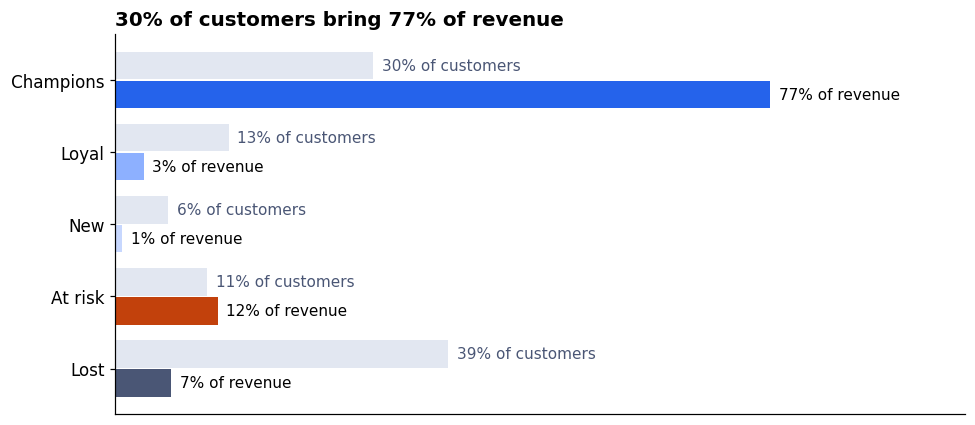

In [8]:
champ = segments.loc["Champions"]
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(SEGMENTS))
ax.barh(y - 0.2, segments.customer_share, height=0.38, color=LIGHT, label="Share of customers")
ax.barh(y + 0.2, segments.revenue_share, height=0.38, color=[SEGMENT_COLOURS[s] for s in SEGMENTS], label="Share of revenue")
for i, s in enumerate(SEGMENTS):
    ax.text(segments.customer_share[s] + 0.01, i - 0.2, f"{segments.customer_share[s]:.0%} of customers", va="center", fontsize=10, color=SLATE)
    ax.text(segments.revenue_share[s] + 0.01, i + 0.2, f"{segments.revenue_share[s]:.0%} of revenue", va="center", fontsize=10)
ax.set_yticks(y, SEGMENTS); ax.invert_yaxis(); ax.set_xticks([]); ax.set_xlim(0, 1)
ax.set_title(f"{champ.customer_share:.0%} of customers bring {champ.revenue_share:.0%} of revenue", loc="left")
plt.tight_layout(); plt.savefig(DOCS / "segments.png"); plt.show()

## Who to call first

At-risk customers were good customers and have stopped buying. The list is sorted by spend, so the biggest are called first.

631 at-risk customers spent 1,978,042 (12.1% of revenue)


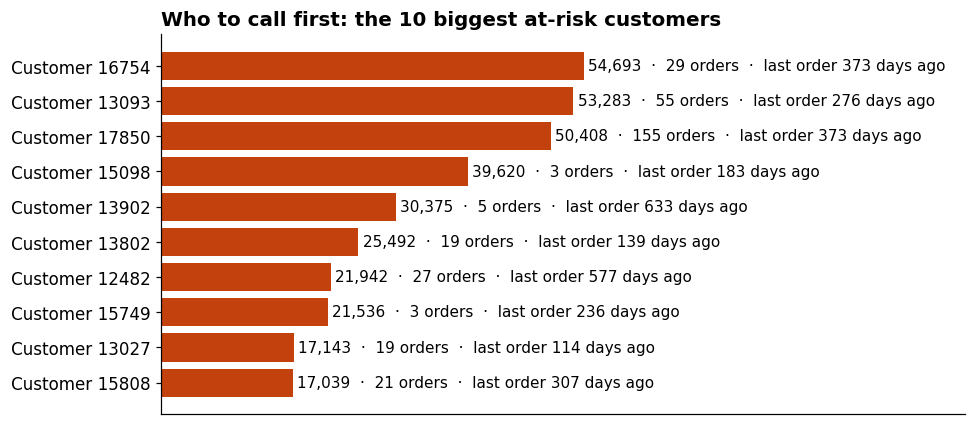

,country,last_purchase,recency_days,orders,spend
customer_id,,,,,
16754,United Kingdom,2010-12-02 17:38:00,373,29,54692.82
13093,United Kingdom,2011-03-09 12:14:00,276,55,53283.30
17850,United Kingdom,2010-12-02 15:27:00,373,155,50407.77
15098,United Kingdom,2011-06-10 15:33:00,183,3,39619.50
13902,Denmark,2010-03-17 13:09:00,633,5,30375.26
13802,United Kingdom,2011-07-24 10:54:00,139,19,25491.56
12482,Sweden,2010-05-12 16:51:00,577,27,21941.72
15749,United Kingdom,2011-04-18 13:20:00,236,3,21535.90
13027,United Kingdom,2011-08-18 09:39:00,114,19,17143.20


In [9]:
at_risk = customers[customers.segment == "At risk"].sort_values("spend", ascending=False)
top10 = at_risk.head(10)
print(f"{len(at_risk):,} at-risk customers spent {at_risk.spend.sum():,.0f} ({at_risk.spend.sum() / total_spend:.1%} of revenue)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([f"Customer {cid}" for cid in top10.index], top10.spend, color=DANGER)
for i, (spend, days, orders) in enumerate(zip(top10.spend, top10.recency_days, top10.orders)):
    ax.text(spend + top10.spend.max() * 0.01, i, f"{spend:,.0f}  ·  {orders} orders  ·  last order {days} days ago", va="center", fontsize=10)
ax.invert_yaxis(); ax.set_xticks([]); ax.set_xlim(0, top10.spend.max() * 1.9)
ax.set_title("Who to call first: the 10 biggest at-risk customers", loc="left")
plt.tight_layout(); plt.savefig(DOCS / "at-risk.png"); plt.show()
top10[["country", "last_purchase", "recency_days", "orders", "spend"]]

## 6. Cohorts: how many of each month's new customers come back

A customer's **starting month** is the month of their first purchase. For each later month we count how many of them bought again.

Two starting months are shown but left out of the average:

- **December 2009:** the data starts there, so that group also holds older customers buying for the first time *in this data*.
- **December 2011:** the data ends on 9 December, so there is no next month yet.

In [10]:
customers["cohort_month"] = customers.first_purchase.dt.to_period("M").dt.to_timestamp()
invoices = invoices[invoices.customer_id.isin(customers.index)].copy()
is_purchase = invoices.invoice_type == "Purchase"
cohort = invoices.customer_id.map(customers.cohort_month)
months = (invoices.invoice_date.dt.year - cohort.dt.year) * 12 + (invoices.invoice_date.dt.month - cohort.dt.month)
invoices["month_offset"] = months.where(is_purchase)  # only purchases get one
purchases = invoices[is_purchase]

active = purchases.groupby([purchases.customer_id.map(customers.cohort_month), "month_offset"]).customer_id.nunique()
retention = active.unstack().div(customers.groupby("cohort_month").size(), axis=0)
retention.index = retention.index.strftime("%b %Y")
retention.columns = retention.columns.astype(int)

new_customers = customers[(customers.cohort_month >= "2010-01-01") & (customers.cohort_month <= "2011-11-01")]
back_next_month = purchases[purchases.customer_id.isin(new_customers.index) & (purchases.month_offset == 1)].customer_id.nunique()
month1_rate = back_next_month / len(new_customers)
repeat_rate = (customers.orders >= 2).mean()
print(f"Repeat customers (two or more orders): {repeat_rate:.1%}")
print(f"New customers (Jan 2010 to Nov 2011) who bought again the next month: {back_next_month:,} of {len(new_customers):,} = {month1_rate:.1%}")
retention.iloc[:, :7].style.format("{:.0%}", na_rep="")

Repeat customers (two or more orders): 72.6%
New customers (Jan 2010 to Nov 2011) who bought again the next month: 1,009 of 4,856 = 20.8%


month_offset,0,1,2,3,4,5,6
customer_id,,,,,,,
Dec 2009,100%,35%,33%,43%,38%,36%,38%
Jan 2010,100%,21%,32%,32%,27%,31%,27%
Feb 2010,100%,23%,23%,29%,25%,20%,19%
Mar 2010,100%,19%,23%,24%,23%,20%,25%
Apr 2010,100%,19%,19%,16%,18%,22%,28%
May 2010,100%,16%,17%,18%,18%,26%,21%
Jun 2010,100%,18%,19%,21%,23%,29%,13%
Jul 2010,100%,16%,18%,30%,29%,14%,11%
Aug 2010,100%,20%,29%,33%,17%,12%,10%


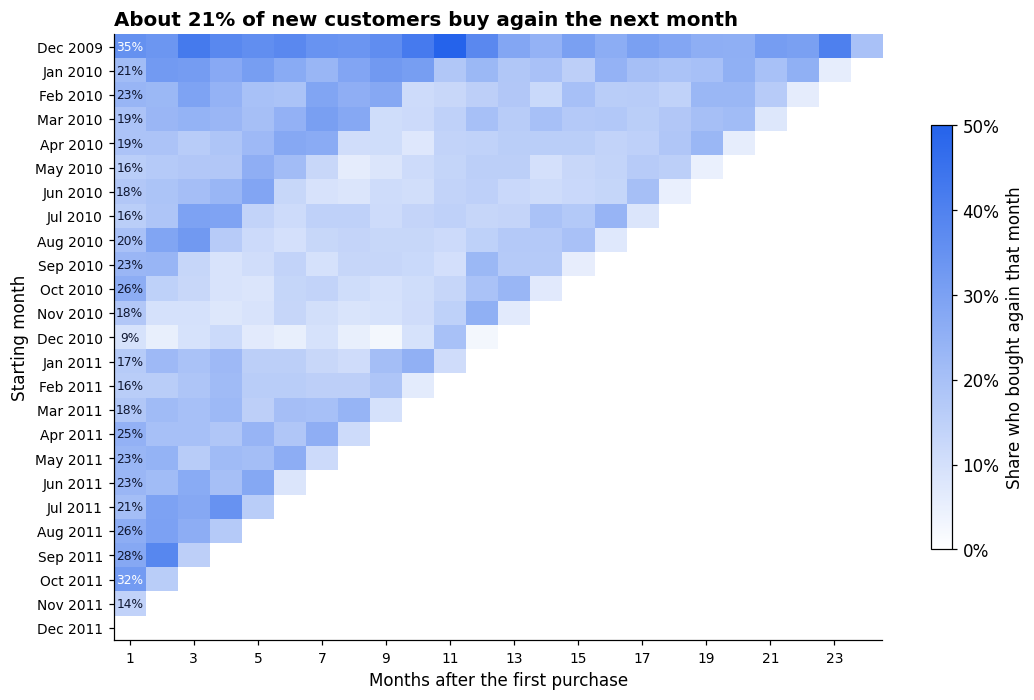

In [11]:
shown = retention.iloc[:, 1:]  # month 0 is always 100%
fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(shown.values, cmap=LinearSegmentedColormap.from_list("white_to_blue", ["#FFFFFF", "#2563EB"]), vmin=0, vmax=0.5, aspect="auto")
ax.set_yticks(range(len(shown)), shown.index, fontsize=9)
ax.set_xticks(range(0, shown.shape[1], 2), shown.columns[::2], fontsize=9)
ax.set_xlabel("Months after the first purchase")
ax.set_ylabel("Starting month")
for i, v in enumerate(shown.iloc[:, 0]):
    if not np.isnan(v):
        ax.text(0, i, f"{v:.0%}", ha="center", va="center", fontsize=8, color="white" if v > 0.3 else NAVY)
fig.colorbar(im, ax=ax, format=lambda v, _: f"{v:.0%}", shrink=0.7, label="Share who bought again that month")
ax.set_title(f"About {month1_rate:.0%} of new customers buy again the next month", loc="left")
plt.tight_layout(); plt.savefig(DOCS / "cohorts.png"); plt.show()

## 7. Check the key numbers again in SQL

The same numbers, recomputed with plain SQL from the two output tables (DuckDB queries the data frames directly). Any difference stops the notebook.

In [12]:
inv = invoices.reset_index(drop=True)
cus = customers.reset_index()

sql_rfm = duckdb.sql("""
    SELECT customer_id,
           COUNT(DISTINCT invoice) FILTER (WHERE invoice_type = 'Purchase') AS orders,
           ROUND(SUM(amount), 2) AS spend,
           DATE '2011-12-10' - MAX(CAST(invoice_date AS DATE)) FILTER (WHERE invoice_type = 'Purchase') AS recency_days
    FROM inv
    GROUP BY customer_id
""").df().set_index("customer_id").sort_index()
mine = customers[["orders", "spend", "recency_days"]].sort_index()
assert (sql_rfm.orders == mine.orders).all() and (sql_rfm.recency_days == mine.recency_days).all()
assert np.allclose(sql_rfm.spend, mine.spend, atol=0.01)
print(f"Recency, frequency and spend match for all {len(mine):,} customers")

sql_segments = duckdb.sql("""
    WITH spend AS (SELECT customer_id, SUM(amount) AS spend FROM inv GROUP BY customer_id)
    SELECT c.segment,
           COUNT(*) AS customers,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM cus), 1) AS customer_share_pct,
           ROUND(100.0 * SUM(s.spend) / (SELECT SUM(amount) FROM inv), 1) AS revenue_share_pct
    FROM cus c JOIN spend s USING (customer_id)
    GROUP BY c.segment
    ORDER BY MIN(c.segment_order)
""").df()
assert (sql_segments.customers.values == segments.customers.values).all()
assert np.allclose(sql_segments.revenue_share_pct.values, (100 * segments.revenue_share).round(1).values)

sql_month1 = duckdb.sql("""
    SELECT COUNT(DISTINCT i.customer_id) * 1.0
           / (SELECT COUNT(*) FROM cus WHERE cohort_month BETWEEN DATE '2010-01-01' AND DATE '2011-11-01') AS month1_rate
    FROM cus c JOIN inv i USING (customer_id)
    WHERE c.cohort_month BETWEEN DATE '2010-01-01' AND DATE '2011-11-01'
      AND i.invoice_type = 'Purchase' AND i.month_offset = 1
""").fetchone()[0]
assert abs(sql_month1 - month1_rate) < 1e-9
print(f"Month-1 return rate in SQL: {sql_month1:.1%}")
sql_segments

Recency, frequency and spend match for all 5,832 customers
Month-1 return rate in SQL: 20.8%


,segment,customers,customer_share_pct,revenue_share_pct
0,Champions,1772,30.4,77.1
1,Loyal,779,13.4,3.4
2,New,364,6.2,0.8
3,At risk,631,10.8,12.1
4,Lost,2286,39.2,6.6


## 8. Save the tables Power BI loads

In [13]:
out_invoices = invoices.assign(invoice_date=invoices.invoice_date.dt.date, amount=invoices.amount.round(2),
                               month_offset=invoices.month_offset.astype("Int64"))
out_invoices[["invoice", "customer_id", "invoice_date", "invoice_type", "amount", "month_offset"]].to_csv(DATA / "invoices.csv", index=False)

out_customers = customers.reset_index()
for col in ["first_purchase", "last_purchase", "cohort_month"]:
    out_customers[col] = out_customers[col].dt.date
out_customers[["customer_id", "country", "first_purchase", "last_purchase", "cohort_month", "recency_days", "orders",
               "spend", "r_score", "f_score", "m_score", "segment", "segment_order"]].to_csv(DATA / "customers.csv", index=False)
print(f"invoices.csv: {len(out_invoices):,} rows, customers.csv: {len(out_customers):,} rows")

invoices.csv: 43,807 rows, customers.csv: 5,832 rows


## The numbers

Every number in the README and in the Power BI checks comes from here.

In [14]:
numbers = {
    "purchase invoices": f"{len(purchases):,}",
    "customers scored": f"{len(customers):,}",
    "revenue (purchases minus returns)": f"{total_spend:,.2f}",
    "champions: customers": f"{int(champ.customers):,}",
    "champions: share of customers": f"{champ.customer_share:.1%}",
    "champions: share of revenue": f"{champ.revenue_share:.1%}",
    "at-risk customers": f"{len(at_risk):,}",
    "at-risk: revenue": f"{at_risk.spend.sum():,.2f}",
    "at-risk: share of revenue": f"{at_risk.spend.sum() / total_spend:.1%}",
    "repeat customers (two or more orders)": f"{repeat_rate:.1%}",
    "new customers back the next month": f"{month1_rate:.1%}",
}
pd.Series(numbers, name="value").to_frame()

,value
purchase invoices,"36,573"
customers scored,"5,832"
revenue (purchases minus returns),"16,361,570.13"
champions: customers,"1,772"
champions: share of customers,30.4%
champions: share of revenue,77.1%
at-risk customers,631
at-risk: revenue,"1,978,041.75"
at-risk: share of revenue,12.1%
repeat customers (two or more orders),72.6%
